# Estimación del parametro Theta (elasticidad del comercio)

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import os, unicodedata, re
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 1. RUTAS A TUS DATOS (Creados por ti)
PATH_ELEC = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/outcomes/elecciones/base_unificada_ma_elecciones_comunas1970.csv'
PATH_MAPPING = '/Users/Angelo/Dropbox/Tesis 2026 ME/Codes/mapping_1970_2024.csv'
PATH_POB = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/población/Consolidado informacion censos historicos .xlsx'
PATH_OD_70 = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/distancia/matriz_OD_1970.csv'
PATH_OD_80 = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/distancia/matriz_OD_1980.csv'


In [ ]:
# 2. FUNCIONES DE NORMALIZACIÓN
SPELLING_ALIASES = {
    'AYSEN': 'AISEN', 'COYHAIQUE': 'COIHAIQUE', 'TREHUACO': 'TREGUACO', 
    'PAIHUANO': 'PAIGUANO', 'MARCHIGUE': 'MARCHIHUE', 'CHIGUAYANTE': 'CONCEPCION', 
    'SAN PEDRO DE LA PAZ': 'CONCEPCION', 'HUALPEN': 'TALCAHUANO', 
    'PADRE LAS CASAS': 'TEMUCO', 'ALTO HOSPICIO': 'IQUIQUE'
}

def normalizar(txt):
    if pd.isna(txt): return ''
    txt = str(txt).strip().upper()
    txt = unicodedata.normalize('NFD', txt)
    txt = ''.join(c for c in txt if unicodedata.category(c) != 'Mn')
    txt = re.sub(r'[^A-Z ]', '', txt)
    return SPELLING_ALIASES.get(txt, txt)

In [ ]:
# 3. CARGAR BASE ELECTORAL 
df_elec = pd.read_csv(PATH_ELEC)
df_elec['log_pob_1970'] = np.log(df_elec['pob_1970'].replace(0, np.nan))
df_elec['region_cat'] = df_elec['region'].astype(str)

# 4. PREPARAR MAPPING Y POBLACIÓN
df_map = pd.read_csv(PATH_MAPPING)
df_map['h_norm'] = df_map['daughter_2024'].apply(normalizar)
df_map['m_norm'] = df_map['mother_1970'].apply(normalizar)
hija_a_madre = pd.Series(df_map.m_norm.values, index=df_map.h_norm.values).to_dict()

df_pob = pd.read_excel(PATH_POB)
df_pob['norm'] = df_pob['Nombre Comuna'].apply(normalizar)
df_pob['madre'] = df_pob['norm'].apply(lambda x: hija_a_madre.get(x, x))
df_pob['p1970'] = pd.to_numeric(df_pob['1970'], errors='coerce').fillna(0)
pop_madre = df_pob.groupby('madre')['p1970'].sum().to_dict()
comunas_con_pob = set(c for c, p in pop_madre.items() if p > 0)

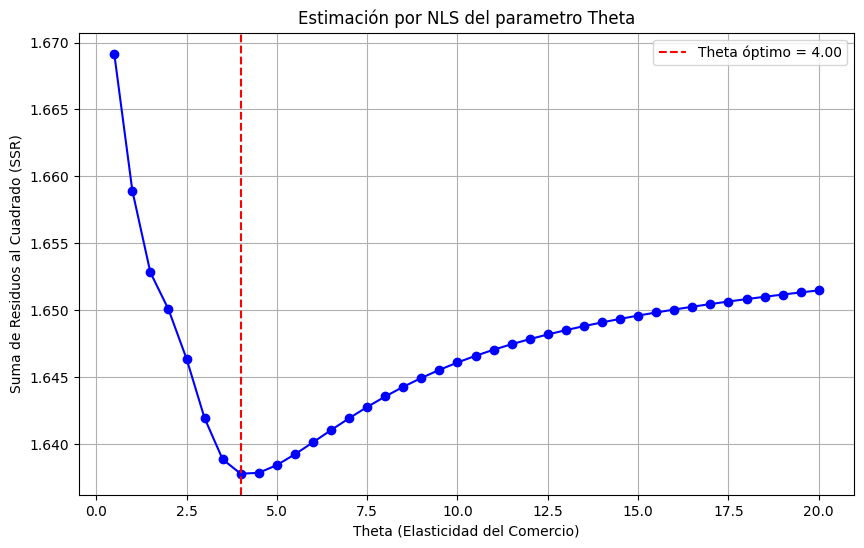

In [14]:
# 7. GRAFICAR EL RESULTADO DIRECTAMENTE EN EL NOTEBOOK
plt.figure(figsize=(10, 6))
plt.plot(res_df['theta'], res_df['SSR'], marker='o', color='b')
plt.axvline(best_theta['theta'], color='red', linestyle='--', label=f'Theta óptimo = {best_theta["theta"]:.2f}')
plt.xlabel('Theta (Elasticidad del Comercio)')
plt.ylabel('Suma de Residuos al Cuadrado (SSR)')
plt.title('Estimación por NLS del parametro Theta')
plt.legend()
plt.grid(True)
plt.show()
